# **CAPM — Capital Asset Pricing Model**

**Autor**: Jorge H. N. Viana

**Resumo**: Este notebook aplica o modelo CAPM (*Capital Asset Pricing Model*)
para estimar o beta ($\beta$) e o alfa ($\alpha$) de ações listadas na B3
(Brasil, Bolsa, Balcão). Os dados de preços são obtidos via Yahoo Finance e a
taxa livre de risco é representada pela SELIC, obtida do Banco Central via
pacote `bcb`.

O notebook está estruturado em três partes:
1. **CAPM para uma única ação (AGRO3)**: estimação completa passo a passo,
   com retornos mensais e SELIC mensalizada;
2. **CAPM para múltiplas ações**: estimação simultânea dos betas de 7 ações,
   com retornos semanais e SELIC semanalizada;
3. **CAPM em janelas deslizantes**: estimação rolling com janela de 30 semanas,
   permitindo visualizar a evolução temporal dos parâmetros.

# 1. CARREGAMENTO DOS PACOTES

Nesta seção são importadas as bibliotecas necessárias para a análise.
Destacam-se:
- `yfinance`: coleta de dados históricos de preços do Yahoo Finance;
- `bcb.sgs`: acesso à API de séries temporais do Banco Central do Brasil
  (para obtenção da taxa SELIC);
- `statsmodels.formula.api` (`smf`): estimação do CAPM via MQO com fórmula
  no estilo R (`y ~ x`);
- `statsmodels.regression.rolling.RollingOLS`: estimação em janelas deslizantes
  para análise da evolução temporal dos parâmetros.

In [1]:
# Pacotes
import numpy as np           
import pandas as pd           
import statsmodels.formula.api as smf   
from bcb import sgs    
import yfinance as yf  
from datetime import date, timedelta
from pathlib import Path
from multiprocessing import cpu_count
import warnings
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
from tqdm import tqdm


ModuleNotFoundError: No module named 'bcb'

## 2. CONFIGURAÇÕES

Definem-se aqui os parâmetros globais do notebook:
- **Período de análise**: 5 anos de dados (da data atual retroagindo 2 anos);
- **Diretórios**: caminhos para dados de entrada (*Input*), dados intermediários
  (*Stage*), resultados (*Output*) e figuras (*Figures*);
- **Número de jobs**: utiliza `cpu_count() - 2` núcleos, para não sobrecarregar
  a máquina durante a validação cruzada paralelizada (usado no notebook de
  modelos ARCH).

In [97]:
# Define o período de tempo para coleta dos dados
fim    = date(2025, 12, 31)
inicio = fim - timedelta(days=365*5)

# Warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

# Diretórios
dir_raiz   = "G:\\Meu Drive\\Ensino\\TAF\\taf-code"
input_dir  = Path(dir_raiz, 'Data\\Input\\')
stage_dir  = Path(dir_raiz, 'Data\\Stage\\')
output_dir = Path(dir_raiz, 'Data\\Output\\')
figure_dir = Path(dir_raiz, 'Figures\\')

# Jobs
jobs = cpu_count() - 2

# 3. CAPM PARA UMA AÇÃO

Nesta seção, o CAPM é estimado para uma única ação (AGRO3.SA) de forma didática,
passo a passo. O modelo teórico é:

$$ E(R_i) - R_f = \alpha_i + \beta_i \big( E(R_m) - R_f \big) $$

onde:
- $E(R_i)$ é o retorno esperado do ativo $i$;
- $R_f$ é a taxa livre de risco (SELIC);
- $E(R_m)$ é o retorno esperado da carteira de mercado (Ibovespa);
- $\alpha_i$ (*alfa*) é o excesso de retorno anormal (Jensen, 1968);
- $\beta_i$ (*beta*) mede a sensibilidade do ativo ao risco sistemático.

Utilizam-se retornos mensais para simplificar a exposição didática.

### 3.1 Dados

Coleta dos preços de fechamento ajustados (*Adj Close*) da ação AGRO3.SA e do
índice Ibovespa (`^BVSP`) via Yahoo Finance. Os dados brutos são visualizados
para inspeção inicial. Simultaneamente, a taxa SELIC é obtida do Banco Central
(código 432) para ser usada como *proxy* da taxa livre de risco.

In [98]:
# Define os ativos a serem utilizados
ativos = ['AGRO3.SA', '^BVSP']  

# Coleta os dados do Yahoo Finance
dados = (yf
         .download(ativos, start=inicio, end=fim, 
                   auto_adjust=False)
         ['Adj Close']
         )
dados.head()

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed


Ticker,AGRO3.SA,^BVSP
Date,,
2021-01-04,15.531752,118558.0
2021-01-05,15.966639,119223.0
2021-01-06,16.165447,119851.0
2021-01-07,16.463655,121956.0
2021-01-08,16.090895,125077.0


In [99]:
# SELIC (código 432)
selic = (sgs.get({'selic': 432}, 
                start=inicio,
                end = fim)
         .reset_index()
         )

selic.head()

,Date,selic
0,2021-01-01,2.0
1,2021-01-02,2.0
2,2021-01-03,2.0
3,2021-01-04,2.0
4,2021-01-05,2.0


### 3.2 Retornos e Taxas Mensais

Calculam-se duas versões dos retornos mensais:
- **Retorno percentual simples**: $R_t = \frac{P_t}{P_{t-1}} - 1$, via `pct_change()`;
- **Log-retorno**: $r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$, aditivo no tempo.

A SELIC anual é convertida para a taxa mensal equivalente:

$$ R_{\text{mensal}} = (1 + R_{\text{anual}})^{1/12} - 1 $$

Este procedimento é padrão em finanças para compatibilizar a periodicidade da
taxa livre de risco com a dos retornos dos ativos.

In [100]:
retornos = (dados
            .resample('ME')
            .last()
            .pct_change()
            .dropna()
            )
retornos.head()

Ticker,AGRO3.SA,^BVSP
Date,,
2021-02-28,-0.146237,-0.051480
2021-03-31,0.032258,0.059972
2021-04-30,0.516285,0.019377
2021-05-31,-0.058055,0.061584
2021-06-30,-0.075501,0.004643


In [101]:
log_retornos = (np.log(dados.resample('ME').last()) 
               - np.log(dados.resample('ME').last().shift(1))                
               ).dropna()
log_retornos.head()

Ticker,AGRO3.SA,^BVSP
Date,,
2021-02-28,-0.158102,-0.052852
2021-03-31,0.031749,0.058242
2021-04-30,0.416263,0.019192
2021-05-31,-0.059808,0.059762
2021-06-30,-0.078503,0.004632


### 3.3 Excesso de Retorno

O excesso de retorno é a variável central do CAPM. Para cada ativo, calcula-se:

$$ e_i = R_i - R_f $$

Ou seja, o retorno do ativo menos a taxa livre de risco. O mesmo é feito para
o Ibovespa, gerando o excesso de retorno do mercado ($e_{\text{BVSP}}$).

Estes excessos serão usados como variáveis dependente ($e_i$) e independente
($e_m$) na regressão do CAPM.

In [102]:
# Converter SELIC anual para taxa mensal
selic = (selic
         .assign(selic   = lambda x: x['selic'] / 100,
                 selic_m = lambda x: (1 + x['selic'])**(1/12) - 1))

# Merge dos retornos com a SELIC e cálculo dos excessos
dados = (retornos
         .rename(columns={'^BVSP': 'BVSP'})
         .reset_index()
         .merge(selic[['Date', 'selic_m']], on='Date', how='inner')
         .assign(e_AGRO3 = lambda x: x['AGRO3.SA'] - x['selic_m'],
                 e_BVSP  = lambda x: x['BVSP'] - x['selic_m'])
         )

dados.head()

,Date,AGRO3.SA,BVSP,selic_m,e_AGRO3,e_BVSP
0,2021-02-28,-0.146237,-0.051480,0.001652,-0.147889,-0.053131
1,2021-03-31,0.032258,0.059972,0.002263,0.029995,0.057709
2,2021-04-30,0.516285,0.019377,0.002263,0.514022,0.017114
3,2021-05-31,-0.058055,0.061584,0.002871,-0.060926,0.058713
4,2021-06-30,-0.075501,0.004643,0.003474,-0.078975,0.001168


### 3.4 Estimação do Modelo

O CAPM é estimado via Mínimos Quadrados Ordinários (MQO) usando a fórmula:

$$ e_{\text{AGRO3}} = \alpha + \beta \cdot e_{\text{BVSP}} + \varepsilon $$

O `statsmodels` fornece o sumário completo da regressão, incluindo:
- **$\beta$ (beta)**: sensibilidade ao mercado — se $\beta > 1$, a ação amplifica
  os movimentos do mercado (ação agressiva); se $\beta < 1$, é defensiva;
- **$\alpha$ (alfa)**: excesso de retorno não explicado pelo mercado — se
  significativamente diferente de zero, indica desempenho anormal (alfa de Jensen);
- **$R^2$**: proporção da variância do retorno explicada pelo mercado.

> **Interpretação**: Um $\beta$ de 0,54 significa que, para cada 1% de variação
> no excesso de retorno do Ibovespa, espera-se que o excesso de retorno da AGRO3
> varie 0,54% na mesma direção. Um $\alpha$ negativo e significativo sugere que
> a ação teve desempenho abaixo do esperado pelo CAPM no período.

In [103]:
# Define o modelo CAPM usando a função OLS do statsmodels
modelo = smf.ols('e_AGRO3 ~ e_BVSP', data=dados).fit()

# Imprime os resultados do modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                e_AGRO3   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     5.151
Date:                Tue, 16 Jun 2026   Prob (F-statistic):             0.0270
Time:                        11:47:11   Log-Likelihood:                 49.801
No. Observations:                  59   AIC:                            -95.60
Df Residuals:                      57   BIC:                            -91.45
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0015      0.014      0.107      0.9

# 4. CAPM PARA MÚLTIPLAS AÇÕES

Nesta seção, o CAPM é estimado para um conjunto de 7 ações simultaneamente.
Diferentemente da seção anterior, utilizam-se **retornos semanais** (log-retornos)
e a SELIC é semanalizada para compatibilizar as periodicidades.

As ações analisadas são: ABCB4, ALUP4, AGRO3, AURE3, BMGB4, CGAS5 e CPFE3,
representando setores diversos (bancos, energia, agropecuária, mineração, gás,
saneamento).

### 4.1 Dados

Coleta dos preços ajustados das 7 ações e do Ibovespa, para o mesmo período de
2 anos. Os dados são baixados em uma única chamada ao Yahoo Finance para
otimizar a requisição.

In [104]:
# SELIC (código 432)
selic = (sgs.get({'selic': 432}, 
                start=inicio,
                end = fim)
         .reset_index()
         )

selic.head()

,Date,selic
0,2021-01-01,2.0
1,2021-01-02,2.0
2,2021-01-03,2.0
3,2021-01-04,2.0
4,2021-01-05,2.0


### 4.2 Retornos e Taxas Semanais

Os retornos são calculados como **log-retornos semanais**, reamostrando os preços
para a frequência semanal (domingo) e aplicando a diferença de logaritmos. A SELIC
anual é convertida para taxas mensal e semanal:

$$ R_{\text{semanal}} = (1 + R_{\text{anual}})^{1/52} - 1 $$

O uso de retornos semanais (em vez de mensais) aumenta o número de observações,
melhorando a precisão das estimativas e viabilizando a análise em janelas
deslizantes na seção seguinte.

In [105]:
selic = (selic
         .assign(selic   = lambda x: x["selic"]/100,
                 selic_m = lambda x: (1 + x["selic"])**(1/12) - 1,
                 selic_w = lambda x: (1 + x["selic"])**(1/52) - 1,
                 )
         )

selic.head()

,Date,selic,selic_m,selic_w
0,2021-01-01,0.02,0.001652,0.000381
1,2021-01-02,0.02,0.001652,0.000381
2,2021-01-03,0.02,0.001652,0.000381
3,2021-01-04,0.02,0.001652,0.000381
4,2021-01-05,0.02,0.001652,0.000381


### 4.3 Excesso de Retorno

Os excessos de retorno semanais são calculados para cada ação e para o Ibovespa:

$$ e_{i,t} = r_{i,t} - R_{f,t}^{\text{semanal}} $$

O código utiliza uma construção dinâmica com `assign(**{...})` para criar as
colunas de excesso de retorno para todos os ativos de uma só vez, evitando
repetição manual. Os nomes das colunas seguem o padrão `e_NOME` (ex.: `e_AGRO3`).

In [106]:
# Excessos de retorno
data = (log_retornos
        .merge(selic, how = "inner", 
               left_on = "Date",
               right_on = "Date")
        .rename(columns = {"^BVSP": "BVSP"})
        .rename(columns=lambda x: x.replace('.SA', ''))
        )

# Colunas de ações (excluindo a coluna 'livre_de_risco')
colunas_acoes = [col for col in data.columns 
                 if col not in ['selic', 'selic_m', 'selic_w', 'Date'] ]

data = (data
        .assign(**{f'e_{col}': lambda x, c=col: x[c] - x['selic_w'] 
                   for col in colunas_acoes })
        .rename(columns=lambda x: x.replace('.SA', ''))
        )

data.head()

,Date,AGRO3,BVSP,selic,selic_m,selic_w,e_AGRO3,e_BVSP
0,2021-02-28,-0.158102,-0.052852,0.0200,0.001652,0.000381,-0.158483,-0.053233
1,2021-03-31,0.031749,0.058242,0.0275,0.002263,0.000522,0.031227,0.057720
2,2021-04-30,0.416263,0.019192,0.0275,0.002263,0.000522,0.415742,0.018670
3,2021-05-31,-0.059808,0.059762,0.0350,0.002871,0.000662,-0.060470,0.059101
4,2021-06-30,-0.078503,0.004632,0.0425,0.003474,0.000801,-0.079304,0.003831


### 4.4 Estimação dos Modelos

Para cada ação, estima-se uma regressão CAPM independente:

$$ e_{\text{ação}} = \alpha + \beta \cdot e_{\text{BVSP}} + \varepsilon $$

Os resultados são consolidados em um DataFrame com as seguintes colunas:
- **Ação**: ticker do ativo;
- **Beta ($\beta$)**: sensibilidade ao risco de mercado;
- **Alfa ($\alpha$)**: excesso de retorno anormal;
- **P-Valor**: significância estatística dos parâmetros;
- **$R^2$**: qualidade do ajuste.

> **Leitura dos resultados**: Betas próximos de 1 indicam que a ação se move
> em linha com o mercado. Ações com beta < 1 são defensivas (ex.: utilities),
> enquanto beta > 1 indica ações agressivas/cíclicas. Alfas não significativos
> sugerem que o CAPM é suficiente para explicar os retornos — não há evidência
> de retornos anormais.

# 5. CAPM EM JANELAS DESLIZANTES

Nesta seção, o CAPM é estimado em **janelas deslizantes** (*rolling windows*) de
30 semanas. Esta abordagem permite analisar a **estabilidade temporal** dos
parâmetros $\alpha$ e $\beta$, revelando se o risco sistemático de cada ação
varia ao longo do tempo.

A estimação rolling é particularmente útil para:
- Detectar mudanças estruturais no perfil de risco das empresas;
- Identificar períodos de maior ou menor sensibilidade ao mercado;
- Avaliar se o beta histórico é representativo do beta futuro (estacionariedade).

### 5.1 Estimação

Utiliza-se `RollingOLS` do `statsmodels` para estimar o modelo CAPM em cada janela
de 30 observações consecutivas. Para cada ação, a janela avança uma observação
por vez, produzindo uma série temporal de parâmetros estimados.

O DataFrame resultante contém, para cada janela:
- **Beta** e **Alfa** estimados;
- **P-Valores** associados a cada parâmetro;
- **Intervalos de confiança** (95%) para beta e alfa;
- **$R^2$** do ajuste naquela janela.

Com 104 semanas de dados e janela de 30, obtêm-se aproximadamente 74 estimativas
por ação, permitindo visualizar tendências e ciclos nos parâmetros.

In [141]:
# Rolling CAPM - janela de 30 semanas
window = 30
results = []
acoes_r = [c for c in colunas_acoes if c != 'BVSP']
for acao in acoes_r:
    y = data[f'e_{acao}']
    X = sm.add_constant(data['e_BVSP'])
    
    rolling = RollingOLS(y, X, window=window).fit()
    
    params  = np.array(rolling.params)    
    pvalues = np.array(rolling.pvalues)   
    ci = rolling.conf_int()
    
    n = len(params)
    for i in range(window - 1, n):
        results.append({
            'Ação': acao,
            'Data_Fim': data['Date'].iloc[i],
            'Beta':   params[i, 1],
            'Alfa':   params[i, 0],
            'P_Beta': pvalues[i, 1],
            'P_Alfa': pvalues[i, 0],
            'Lower_Alfa': ci[('const',   'lower')].values[i],
            'Upper_Alfa': ci[('const',   'upper')].values[i],
            'Lower_Beta': ci[('e_BVSP',  'lower')].values[i],
            'Upper_Beta': ci[('e_BVSP',  'upper')].values[i]
        })

resultados_rolling = (pd.DataFrame(results)
                       .sort_values(['Ação', 'Data_Fim'])
                       .reset_index(drop=True))

resultados_rolling.head()

,Ação,Data_Fim,Beta,Alfa,P_Beta,P_Alfa,Lower_Alfa,Upper_Alfa,Lower_Beta,Upper_Beta
0,AGRO3,2023-07-31,0.858052,0.007176,0.041903,0.751696,-0.037274,0.051625,0.031429,1.684675
1,AGRO3,2023-08-31,0.814945,0.009562,0.049728,0.668777,-0.034244,0.053368,0.000968,1.628921
2,AGRO3,2023-09-30,0.847079,0.016224,0.052858,0.482350,-0.029039,0.061487,-0.010450,1.704609
3,AGRO3,2023-10-31,0.754296,0.002160,0.033196,0.908389,-0.034630,0.038950,0.060117,1.448474
4,AGRO3,2023-11-30,0.676065,0.001660,0.043821,0.929622,-0.035175,0.038495,0.018725,1.333404


### 5.2 Gráficos

Para cada ação, são gerados dois gráficos empilhados:
- **Painel superior**: evolução do $\beta$ ao longo do tempo, com bandas de
  confiança (95%), permitindo avaliar se as variações são estatisticamente
  significativas;
- **Painel inferior**: evolução do $\alpha$ com respectivas bandas de confiança.

As figuras são salvas em alta resolução (400 dpi) no diretório `Figures/` com
nomenclatura padronizada (`capm_weekly_rolling_NOME.png`).

> **Interpretação visual**: Se as bandas de confiança do $\beta$ não incluem
> o valor 0 ao longo de todo o período, o risco sistemático é consistentemente
> significativo. Variações expressivas no $\beta$ podem indicar mudanças
> na estrutura de negócios ou no ambiente regulatório da empresa.

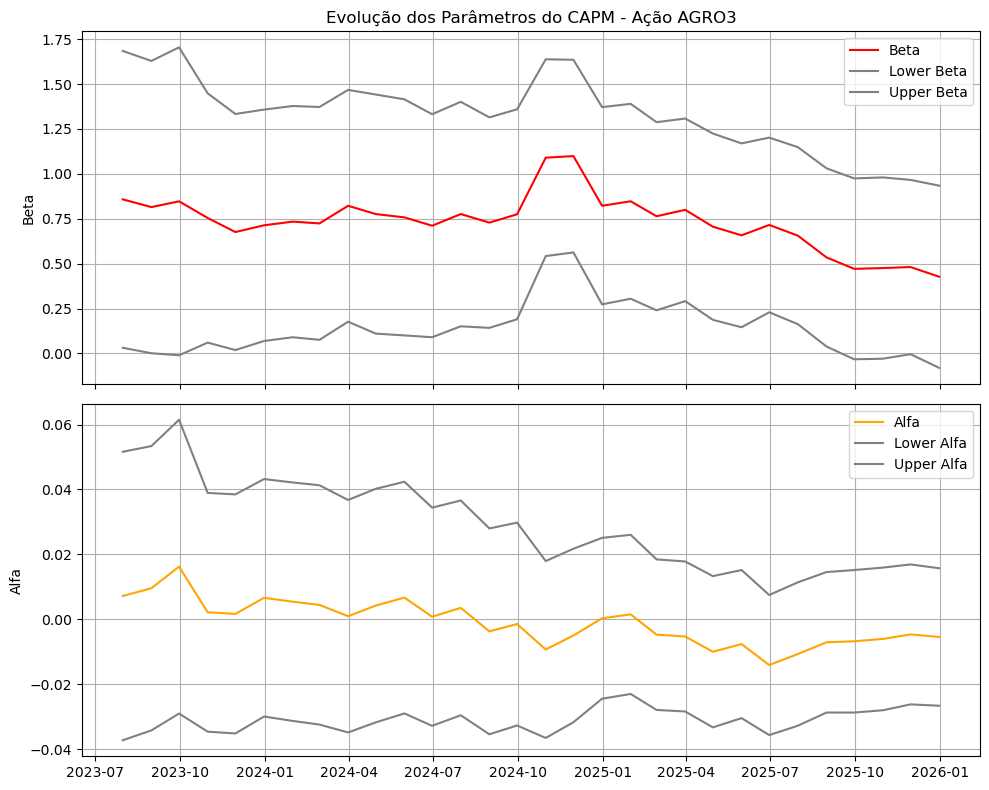

In [142]:
import matplotlib.pyplot as plt

# Criando os gráficos
for acao in resultados_rolling['Ação'].unique():
    plt.close()
    df_acao = resultados_rolling[resultados_rolling['Ação'] == acao]

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

    # Gráfico do Beta
    axes[0].plot(df_acao['Data_Fim'], df_acao['Beta'], label='Beta', color='red')
    axes[0].plot(df_acao['Data_Fim'], df_acao['Lower_Beta'], label='Lower Beta', color='grey')
    axes[0].plot(df_acao['Data_Fim'], df_acao['Upper_Beta'], label='Upper Beta', color='grey')
    axes[0].set_ylabel('Beta')
    axes[0].set_title(f'Evolução dos Parâmetros do CAPM - Ação {acao}')
    axes[0].legend()
    axes[0].grid(True)

    # Gráfico do Alfa
    axes[1].plot(df_acao['Data_Fim'], df_acao['Alfa'], label='Alfa', color='orange')
    axes[1].plot(df_acao['Data_Fim'], df_acao['Lower_Alfa'], label='Lower Alfa', color='grey')
    axes[1].plot(df_acao['Data_Fim'], df_acao['Upper_Alfa'], label='Upper Alfa', color='grey')
    axes[1].set_ylabel('Alfa')
    axes[1].legend()
    axes[1].grid(True)
    
    fig.get_figure().savefig( Path(figure_dir, 'capm_weekly_rolling_' + acao + '.png'), dpi = 400)
    plt.tight_layout()

plt.show()

# 6. LIMITAÇÕES  E PRÓXIMOS PASSOS

## Limitações

- O CAPM é um modelo de um único fator (mercado) — modelos multifatoriais
  (Fama-French, Carhart) podem capturar dimensões adicionais de risco;
- O uso do Ibovespa como *proxy* do mercado e da SELIC como taxa livre de risco
  são aproximações que podem não refletir perfeitamente os conceitos teóricos;
- O período de 2 anos pode ser insuficiente para capturar ciclos econômicos
  completos ou eventos raros (*tail events*);
- A janela de 30 semanas para o CAPM rolling é arbitrária e pode ser otimizada.

## Extensões sugeridas

1. Estimar o CAPM para todas as ações da B3 (generalizar o código da Seção 4);
2. Implementar o modelo de 3 fatores de Fama-French para o mercado brasileiro;
3. Testar diferentes tamanhos de janela no CAPM rolling e avaliar o *trade-off*
   entre viés e variância das estimativas;
4. Adicionar testes formais de estabilidade estrutural (Chow, CUSUM) para
   identificar quebras nos parâmetros;
5. Comparar os betas estimados com betas fundamentalistas (alavancagem, setor).